
开始训练岭回归模型（lambda_=1.0）...
迭代第0次，损失值：2.8149
迭代第100次，损失值：0.6520
迭代第200次，损失值：0.3561
迭代第300次，损失值：0.3096
迭代第400次，损失值：0.2977
迭代第500次，损失值：0.2915
迭代第600次，损失值：0.2867
迭代第700次，损失值：0.2827
迭代第800次，损失值：0.2793
迭代第900次，损失值：0.2764

岭回归模型评估结果：
训练集MSE：0.5477
测试集MSE：0.5672
训练集R²：0.5903
测试集R²：0.5672

不同正则化强度的测试集R²：
迭代第0次，损失值：2.8149
迭代第100次，损失值：0.6520
迭代第200次，损失值：0.3561
迭代第300次，损失值：0.3096
迭代第400次，损失值：0.2977
迭代第500次，损失值：0.2914
迭代第600次，损失值：0.2866
迭代第700次，损失值：0.2826
迭代第800次，损失值：0.2792
迭代第900次，损失值：0.2763
lambda=0.001，测试集R²=0.5672
迭代第0次，损失值：2.8149
迭代第100次，损失值：0.6520
迭代第200次，损失值：0.3561
迭代第300次，损失值：0.3096
迭代第400次，损失值：0.2977
迭代第500次，损失值：0.2914
迭代第600次，损失值：0.2866
迭代第700次，损失值：0.2826
迭代第800次，损失值：0.2792
迭代第900次，损失值：0.2763
lambda=0.010，测试集R²=0.5672
迭代第0次，损失值：2.8149
迭代第100次，损失值：0.6520
迭代第200次，损失值：0.3561
迭代第300次，损失值：0.3096
迭代第400次，损失值：0.2977
迭代第500次，损失值：0.2914
迭代第600次，损失值：0.2866
迭代第700次，损失值：0.2826
迭代第800次，损失值：0.2792
迭代第900次，损失值：0.2763
lambda=0.100，测试集R²=0.5672
迭代第0次，损失值：2.8149
迭代第100次，损失值：0.6520
迭代第200次，损失值：0.3561
迭代第300

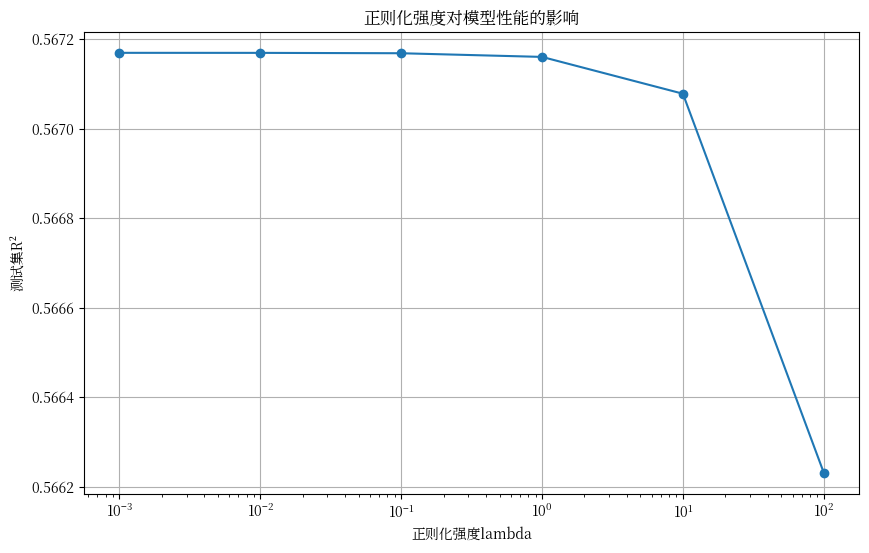

In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Noto Serif CJK JP']        # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False          # 用来正常显示负号
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# 岭回归类（L2正则化）
class MyRidgeRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000, lambda_=1.0):
        """
        初始化岭回归模型
        :param learning_rate: 学习率
        :param n_iterations: 迭代次数
        :param lambda_: 正则化强度，lambda_=0时退化为普通线性回归
        """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.lambda_ = lambda_  # 正则化参数
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        """
        训练模型（带L2正则化的梯度下降）
        """
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0

        for i in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias

            # 带正则化的损失函数
            loss = (1/(2*m)) * np.sum((y_pred - y)**2) + (self.lambda_/(2*m)) * np.sum(self.weights**2)
            self.loss_history.append(loss)

            # 带正则化的梯度（偏置项b不参与正则化）
            dw = (1/m) * np.dot(X.T, (y_pred - y)) + (self.lambda_/m) * self.weights
            db = (1/m) * np.sum(y_pred - y)

            # 更新参数
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            if i % 100 == 0:
                print(f"迭代第{i}次，损失值：{loss:.4f}")

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# 1. 加载并预处理数据集
california = fetch_california_housing()
X = california.data
y = california.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. 训练岭回归模型
print("\n开始训练岭回归模型（lambda_=1.0）...")
ridge_model = MyRidgeRegression(learning_rate=0.01, n_iterations=1000, lambda_=1.0)
ridge_model.fit(X_train_scaled, y_train)

# 3. 模型预测与评估
y_train_pred = ridge_model.predict(X_train_scaled)
y_test_pred = ridge_model.predict(X_test_scaled)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n岭回归模型评估结果：")
print(f"训练集MSE：{train_mse:.4f}")
print(f"测试集MSE：{test_mse:.4f}")
print(f"训练集R²：{train_r2:.4f}")
print(f"测试集R²：{test_r2:.4f}")

# 对比不同lambda值的效果
print("\n不同正则化强度的测试集R²：")
lambdas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
r2_scores = []
for lam in lambdas:
    model = MyRidgeRegression(learning_rate=0.01, n_iterations=1000, lambda_=lam)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    print(f"lambda={lam:.3f}，测试集R²={r2:.4f}")

# 绘制lambda与R²的关系图
plt.figure(figsize=(10, 6))
plt.plot(lambdas, r2_scores, marker='o')
plt.xscale('log')
plt.xlabel('正则化强度lambda')
plt.ylabel('测试集R²')
plt.title('正则化强度对模型性能的影响')
plt.grid(True)
plt.show()